# StockSense — Predicting Daily Stock Movement with Machine Learning

**Goal:** Build a complete ML pipeline that predicts whether a stock will close *higher or lower* the next trading day.

**Why this problem?**
I chose this problem because stock price movement is one of the most studied, most difficult prediction tasks in ML. It's noisy, non-stationary, and full of many, common pitfalls with data. This makes it an excellent project for learning: every concept I studied here — data leakage, feature engineering, class imbalance, overfitting — is something engineers genuinely wrestle with in production systems.

**End deliverable:** A single, fully documented Jupyter notebook — raw data in, trained models and evaluation charts out.

## 0. Imports

All dependencies are declared at the top of the notebook in a single cell. This is standard practice in data science notebooks. Full requirements can be found in the requirments.txt file in the project root directory.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as npy
import matplotlib.pyplot as plt
import seaborn as sbn

## 1.1 — Acquiring the Data

**What we're doing:** Downloading 5 years of daily OHLCV data for Apple Inc. (AAPL) from Yahoo Finance via the `yfinance` API.

**Why Apple (AAPL)?**
- Highly liquid — prices reflect genuine market activity
- Has 5 years of history that gives ~1,260 trading days, which is enough for meaningful ML without being unwieldy
- No survivorship bias concern for a single ticker used as a learning exercise
- Free and accessible via `yfinance`

**OHLCV defined:**
| Column | Meaning |
|--------|---------|
| Open | Price at market open |
| High | Intraday highest price |
| Low | Intraday lowest price |
| Close | Price at market close |
| Volume | Number of shares traded |
| Adj Close | Close adjusted for dividends and stock splits |

> 🔑 **Decision — raw Close vs Adj Close:**
> We are using `Adj Close` for feature calculations rather than `Close`. When a company pays a dividend or does a stock split, the raw Close price jumps discontinuously — not because of market sentiment, but because of a mechanical accounting event. `Adj Close` retroactively adjusts all historical prices to remove these jumps, giving a clean continuous series. Using raw `Close` here would introduce artificial signals into our features.

In [2]:
df = yf.download('AAPL', period='5y')

[*********************100%***********************]  1 of 1 completed


### Inspecting the data — never skip this

Before any transformation, we run three standard inspection calls. This is called a **sanity check**, and skipping it is one of the most common mistakes junior engineers make. You will waste hours debugging a model that has a broken input, not a broken architecture.

- `df.head()` — confirm the column names, index type (should be `DatetimeIndex`), and that values look reasonable
- `df.info()` — check dtypes and the count of non-null entries per column. Any column with missing values will show a lower count than the total rows
- `df.describe()` — check the statistical summary: min, max, mean, std. A negative minimum Volume, for example, would immediately flag a data issue

> 🔑 **What we're watching for:**
> - Missing values (`NaN`s) — yfinance data is generally clean, but market holidays and early data can introduce gaps
> - Unexpected dtypes — all price/volume columns should be `float64`
> - Extreme outliers — a single row where High < Low would indicate a data error

In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-04-05,122.626053,122.879294,119.869643,120.648843,88651200
2021-04-06,122.927971,123.824045,122.382536,123.210430,80171300
2021-04-07,124.574020,124.593497,121.885791,122.557850,83466700
2021-04-08,126.970047,126.999266,125.177899,125.596710,88844600
2021-04-09,129.541443,129.580396,126.103239,126.424659,106686700


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1256 entries, 2021-04-05 to 2026-04-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1256 non-null   float64
 1   (High, AAPL)    1256 non-null   float64
 2   (Low, AAPL)     1256 non-null   float64
 3   (Open, AAPL)    1256 non-null   float64
 4   (Volume, AAPL)  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,186.108945,187.940179,184.114872,185.932790,6.673499e+07
std,41.699174,42.018311,41.386100,41.726049,2.834047e+07
min,119.780540,121.605009,119.273206,120.161073,1.791060e+07
25%,150.120003,151.859058,148.217988,149.937276,4.691878e+07
50%,175.898392,177.613428,174.386080,175.686676,6.001490e+07
75%,220.658684,222.945456,218.291077,220.165935,7.975090e+07
max,285.922455,288.350192,283.035157,285.932471,3.186799e+08


In [6]:
data_size = len(df)
train_df = df.iloc[:int(data_size * 0.7)]
val_df = df.iloc[int(data_size * 0.7):int(data_size * 0.85)]
test_df = df.iloc[int(data_size * 0.85):]

In [7]:
print(f'Train set shape: {train_df.shape}')
print(f'Val set shape:   {val_df.shape}')
print(f'Test set shape:  {test_df.shape}')
if train_df.shape[0] + val_df.shape[0] + test_df.shape[0] == data_size:
    print('Data split correctly!')
else:
    print('Data was not split correctly!')

Train set shape: (879, 5)
Val set shape:   (188, 5)
Test set shape:  (189, 5)
Data split correctly!


In [8]:
short_window = 10
long_window = 50
df['SMA10'] = df['Close'].rolling(window=short_window).mean()
df['SMA50'] = df['Close'].rolling(window=long_window).mean()
df[['Close', 'SMA10', 'SMA50']].head(50)

Price,Close,SMA10,SMA50
Ticker,AAPL,,
Date,,,
2021-04-05,122.626053,NaN,NaN
2021-04-06,122.927971,NaN,NaN
2021-04-07,124.574020,NaN,NaN
2021-04-08,126.970047,NaN,NaN
2021-04-09,129.541443,NaN,NaN
2021-04-12,127.827187,NaN,NaN
2021-04-13,130.934219,NaN,NaN
2021-04-14,128.596634,NaN,NaN


In [9]:
fast_decay = 12
slow_decay = 26
df['EMA12'] = df['Close'].ewm(span=fast_decay).mean()
df['EMA26'] = df['Close'].ewm(span=slow_decay).mean()
df['MACD'] = df['EMA12'] - df['EMA26'] # EMA_12 > EMA_26 => Bullish; EMA_12 < EMA_26 => Bearish
df[['Close', 'EMA12', 'EMA26', 'MACD']].head(50)

Price,Close,EMA12,EMA26,MACD
Ticker,AAPL,,,
Date,,,,
2021-04-05,122.626053,122.626053,122.626053,0.000000
2021-04-06,122.927971,122.789592,122.782818,0.006774
2021-04-07,124.574020,123.486055,123.426380,0.059675
2021-04-08,126.970047,124.585815,124.417034,0.168781
2021-04-09,129.541443,125.932241,125.605406,0.326836
2021-04-12,127.827187,126.392813,126.050411,0.342402
2021-04-13,130.934219,127.406212,126.918971,0.487241
2021-04-14,128.596634,127.654634,127.189284,0.465351


In [13]:
# Finding daily change in price
daily_change = df['Close'].diff()
rsi_window = 14
# Separating daily_change col into two separate col's: gain/loss
gain =daily_change.where(daily_change > 0, 0)
loss = -daily_change.where(daily_change < 0, 0)
# Compute rolling avg's
avg_gain = gain.rolling(window=rsi_window).mean()
avg_loss = loss.rolling(window=rsi_window).mean()
# Compute RS
rs = avg_gain / avg_loss
# Compute RSI so values are 0 -> 100 and not 0 -> inf
df['RSI'] = 100 - (100 / (1 + rs))

In [11]:
# Verify 0 <= x <= 100
df['RSI'].describe()

count    1243.000000
mean       53.293082
std        17.727137
min         6.467084
25%        39.814993
50%        53.858085
75%        67.060764
max        96.162875
Name: RSI, dtype: float64

<Axes: xlabel='Date'>

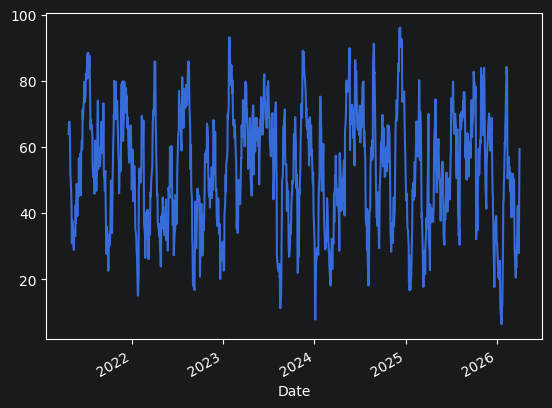

In [12]:
# Visualization: verifying values are generally between 20-80
df['RSI'].plot()